# Training a stochastic graph network for MaxCut


<div class="note"><span class="note-t">In brief</span>
<p>We train a graph circuit for MaxCut, the problem of splitting a graph's nodes into two groups so that as many edges as possible run between the groups. One sweep applies 12 sequential <code>PISING</code> edge updates, and the circuit repeats that sweep 20 times. Training uses REINFORCE, which raises the probability of the sampled partitions that cut more edges than the batch average, and because the graph has only 8 nodes the exact Torx simulator supplies and differentiates the full probability vector behind every score.</p>
</div>

In this tutorial, we train a **stochastic graph network** for MaxCut. MaxCut asks us to split a graph's nodes into two groups so that as many edges as possible have one endpoint in each group, and the number of such crossing edges is the cut we are trying to make large.

One **[probabilistic bit (p-bit)](https://doi.org/10.1063/1.4975355)**, a Bernoulli-valued state, sits on each graph node and records which of the two groups that node currently belongs to. The circuit places one edge-local `PISING` gate on each of the graph's 12 edges. A sweep applies those 12 gates sequentially in fixed edge-list order, and the circuit repeats that sweep 20 times.

The cut of any single sampled partition is a count rather than a differentiable function of the couplings, so we train them with the [REINFORCE gradient estimator (Williams 1992)](#ref-williams-1992), a rule for learning from distributions you can sample but cannot differentiate through: draw samples from the circuit, score each one by its cut, and raise the probability of the samples that scored above the batch average. In this demonstration, `StateVectorSimulator` computes the exact 256-entry probability vector, sampling uses that vector, and JAX differentiates its exact log probabilities.

This tutorial uses Torx, JAX, Optax, and NumPy. The graph helper uses NetworkX. It assumes basic graph and probability notation.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li><strong>Torx:</strong> <code>StateVectorSimulator</code> computes the full classical probability vector for the 8-node circuit.</li><li><strong>Notebook code:</strong> JAX differentiates exact log probabilities in the REINFORCE surrogate, and Optax applies Adam updates.</li><li><strong>Computational helper:</strong> <code>examples/helpers/_nb09_maxcut.py</code> builds the circuit, exact diagnostic, graph reference, and result figures.</li><li><strong>Plot helper:</strong> <code>examples/helpers/_plots_schematics.py</code> draws the edge-local circuit primitive.</li></ul></details>

By the end, you'll be able to:

- build a circuit with 12 sequential `PISING` edge updates per sweep and repeat it for 20 sweeps,
- estimate the expected-cut gradient from sampled bitstrings, using the batch's own mean cut as the baseline, and
- train the edge couplings so the circuit puts more probability on high-cut partitions.

A stochastic graph network is an edge-tiled message-passing circuit.

- Each edge carries one learnable coupling $J_{ij}$.
- Each `PISING` kernel is an edge update: a $4\times4$ column-stochastic Markov matrix, meaning each column of probabilities sums to one. It pushes its two endpoints toward agreement when $J>0$ and disagreement when $J<0$.
- One sweep applies all 12 edge updates sequentially in fixed order. Repeating sweeps makes the network deeper.
- The readout is the cut value, the number of edges whose endpoints disagree.
- Training raises the expected cut.

The quantity we want to raise is an average over sampled bitstrings, and the cut of any one bitstring is a discrete count, which is the situation REINFORCE was designed for. It scores each sampled bitstring by its cut, subtracts the mean cut of the same batch as a baseline, and uses the difference to weight the gradient of that sample's log probability, so partitions that beat the batch average become more likely and the rest become less likely. Subtracting a baseline that those same samples produced would bias the estimate slightly, so we scale the result by a small correction factor that removes the bias exactly. We write the estimator out in full where the training loop implements it. An `optax` optimizer then applies the updates.

## Setup

The setup cells wire up the helper path and apply the shared figure style. The MaxCut utilities come from `examples/helpers/_nb09_maxcut.py`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import jax
import jax.numpy as jnp
import optax

from torx.psc import DiscretePCircuit, PISING



In [2]:
ROOT = Path.cwd()
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [3]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
import _plots_schematics as P_sch
from _nb09_maxcut import (
    random_regular_maxcut,
    brute_force_cuts,
    make_expected_cut,
    cut_distribution,
    edge_pising_matrix,
    plot_training_trajectory,
    plot_cut_distribution,
    plot_partition,
)



In [4]:
FIGURE_DIR = figure_dir(ROOT)
apply_notebook_style()

This small wrapper saves each figure to the gallery directory and displays it inline.

In [5]:
savefig = make_savefig(FIGURE_DIR)

These constants fix the graph instance, the `PISING` gate, and the training budget.

In [6]:
# Graph and gate (locked across the notebook).
NUM_NODES = 8
DEGREE = 3
GRAPH_SEED = 7
BETA = 1.5
DT = 0.5
REPS = 20          # sweeps of the edge layer



In [7]:
# REINFORCE training budget.
J_INIT = -0.2      # small antiferromagnetic start
LEARNING_RATE = 0.1
TRAIN_STEPS = 250
NUM_SAMPLES = 512  # circuit samples per REINFORCE gradient estimate
TRAIN_SEED = 0     # PRNG seed for the sampling

## One PISING per edge

Before assembling the network, we look at the single gate it is tiled from and at the loss that gate has to lower.

We write each spin as $s_i = 2\sigma_i - 1 \in \{-1, +1\}$, so that maximizing the expected cut is the same as minimizing the loss

$$
\mathcal{L} = \underbrace{-\,\mathbb{E}_{p_\theta}[\mathrm{cut}]}_{\vphantom{\big|}\text{negative cut}} = -\sum_{(i,j)\in\mathcal{E}}\underbrace{\frac{1 - \langle s_i s_j\rangle_{p_\theta}}{2}}_{\vphantom{\big|}\text{per-edge cut}},
$$

where $\langle s_i s_j\rangle_{p_\theta}$ is the spin-spin correlation under the circuit. A cut edge ($s_i \neq s_j$) contributes $1$ and an aligned edge contributes $0$, so lowering $\mathcal{L}$ makes endpoints disagree, which is exactly what an antiferromagnetic coupling does.

The primitive is the `PISING` operation: we construct `gate = PISING([i, j])` and supply the theta `[J, h_i, h_j, beta, dt]` separately to `get_matrix` or `build_circuit`. It is a $4\times4$ column-stochastic [Glauber kernel](#ref-glauber-1963), a single-spin thermal flip rule, on a pair of p-bits. With local fields $h=0$ it biases the joint state toward agreement when $J>0$ and disagreement when $J<0$.

How hard each update pushes is set by the inverse temperature $\beta$, where higher is greedier, together with the timestep $\Delta t$. For this 3-regular 8-node graph, one sweep applies 12 `PISING` gates sequentially in the printed `edges` order, and the same fixed order repeats for 20 sweeps. The order matters because these stochastic matrices generally do not commute.

The next cell constructs one edge-local kernel and inspects its stochastic matrix.

In [8]:
# Structure-only gate on sites [0, 1]; its [J, h_i, h_j, beta, dt] parameters
# are a separate theta passed to get_matrix (the real Torx parameter model).
gate_demo = PISING([0, 1])
theta_demo = jnp.array([1.0, 0.0, 0.0, BETA, DT])
M_demo = np.asarray(gate_demo.get_matrix(theta_demo))

print(f"shape: {M_demo.shape}")
print(f"column sums: {np.round(M_demo.sum(axis=0), 8)}")
print(np.round(M_demo, 4))

shape: (4, 4)
column sums: [0.99999994 1.         0.99999994 0.99999994]
[[0.9619 0.3011 0.3011 0.0082]
 [0.015  0.3918 0.0061 0.015 ]
 [0.015  0.0061 0.3918 0.015 ]
 [0.0082 0.3011 0.3011 0.9619]]


In [9]:
np.testing.assert_allclose(
    M_demo.sum(axis=0),
    1.0,
    atol=1e-6,
    err_msg="PISING columns must sum to 1 (column-stochastic)",
)



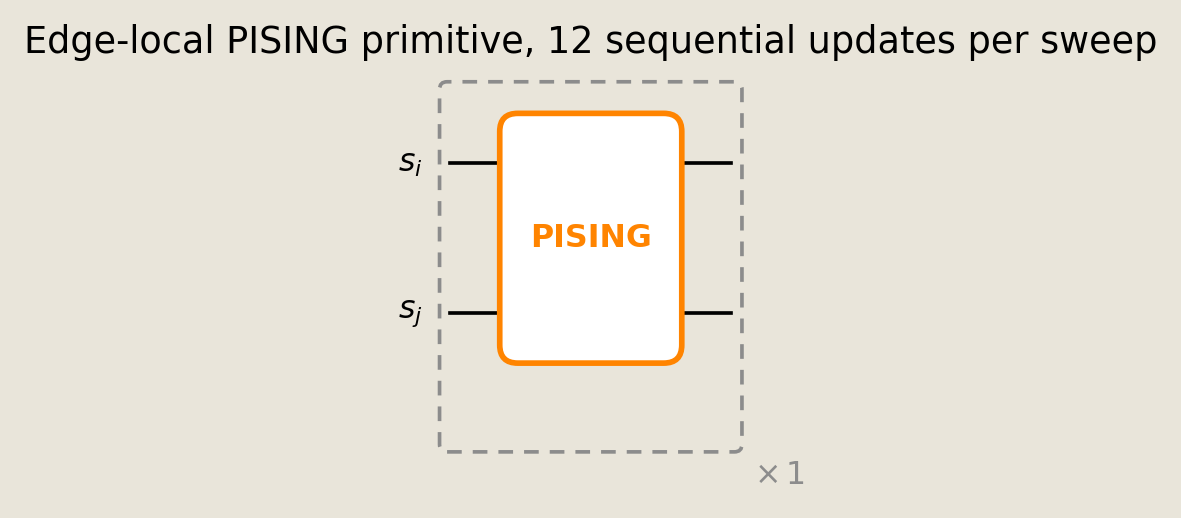

In [10]:
# Draw one edge-local primitive. The full circuit applies 12 distinct edge
# updates sequentially per sweep, then repeats that sweep 20 times.
edge_circuit = DiscretePCircuit([gate_demo], reps=1)
fig = P_sch.draw_pcircuit(
    edge_circuit,
    reps=1,
    wire_labels=[r"$s_i$", r"$s_j$"],
    title="Edge-local PISING primitive, 12 sequential updates per sweep",
)
savefig(fig, "09_sgnn_schematic")

The schematic isolates the one edge-local update that the rest of the circuit is built from. A sweep is the fixed ordered list of 12 edges printed below rather than 12 simultaneous gates, so the picture shows a primitive, not a layer.

The instance is small enough that we never have to guess at a reference. With 8 nodes the exact classical probability vector has only $2^8 = 256$ entries, so we can compute the full distribution, the brute-force optimum, and the exact log-probability scores directly, and every later claim can be checked against an exact number instead of an estimate.

In [11]:
G, edges = random_regular_maxcut(NUM_NODES, DEGREE, seed=GRAPH_SEED)
num_edges = len(edges)
print(f"edge order ({num_edges} sequential updates per sweep): {edges}")

edge order (12 sequential updates per sweep): [(0, 3), (0, 6), (0, 5), (1, 2), (1, 4), (1, 3), (2, 4), (2, 5), (3, 6), (4, 7), (5, 7), (6, 7)]


We brute-force all $2^8$ bitstrings for the exact optimum and how many of them reach it.

In [12]:
cut_values, opt_cut, n_optimal = brute_force_cuts(edges, NUM_NODES)

print(f"graph     : {DEGREE}-regular  N={NUM_NODES}  seed={GRAPH_SEED}")
print(f"edges     : {num_edges}")
print(f"MaxCut    : {opt_cut} / {num_edges}")
print(f"# optimal : {n_optimal} bitstrings out of 2^{NUM_NODES}")

graph     : 3-regular  N=8  seed=7
edges     : 12
MaxCut    : 10 / 12
# optimal : 4 bitstrings out of 2^8


## The exact classical probability vector

Everything downstream, both the training gradient and the diagnostic curve, comes out of one helper, so we build that helper first.

`make_expected_cut` returns two pure-`jax` functions of the couplings: `density(J)`, the circuit's exact 256-entry classical probability vector, and `expected_cut(J)`, the cut averaged over it. Its core is excerpted from `examples/helpers/_nb09_maxcut.py`:

```python
def make_expected_cut(
    edges: _Edges, num_nodes: int, *, beta: float, dt: float, reps: int
):
    ...
    sim = StateVectorSimulator()
    spins = jnp.asarray(spin_table(num_nodes))
    x0 = jnp.ones(2**num_nodes) / float(2**num_nodes)
    edge_sites = [[int(i), int(j)] for i, j in edges]
    # gate structure is static; trainable couplings J enter through theta pytrees
    circuit = DiscretePCircuit([PISING(sites) for sites in edge_sites], reps=reps)
    edge_i = jnp.asarray([i for i, _ in edge_sites])
    edge_j = jnp.asarray([j for _, j in edge_sites])

    def density(J):
        thetas = [
            jnp.stack([J[e], 0.0, 0.0, jnp.asarray(beta), jnp.asarray(dt)])
            for e in range(len(edge_sites))
        ]
        compiled = sim.build_circuit(circuit, thetas)
        return sim.density(compiled, x0)

    def expected_cut(J):
        rho = density(J)
        edge_products = spins[:, edge_i] * spins[:, edge_j]
        correlations = rho @ edge_products
        return jnp.sum((1.0 - correlations) / 2.0)

    return expected_cut, density
```

Within each sweep, `DiscretePCircuit` applies the 12 `PISING` gates sequentially in `edges` order, then repeats that ordered sweep `REPS` times.

Training draws samples from `density` and differentiates the selected entries of its exact full log-probability vector, so gradients reach the couplings only through those sampled log probabilities, whereas `expected_cut` never touches an update and is evaluated purely to record the exact simulator diagnostic that we plot beside the sampled batch objective.

Before training starts, we evaluate that diagnostic at the initial couplings and compare it with the mean cut of a uniform random assignment and with the brute-force optimum, which gives us the two reference levels the training curves are read against.

In [13]:
# Build the exact readout once, then reuse it for all couplings.
expected_cut, density = make_expected_cut(edges, NUM_NODES, beta=BETA, dt=DT, reps=REPS)

J_init = jnp.full((num_edges,), J_INIT)
uniform_mean = float(cut_values.mean())

print(f"expected cut at initialization: {float(expected_cut(J_init)):.2f}")
print(f"uniform baseline (mean cut):    {uniform_mean:.2f}")
print(f"brute-force optimum:            {opt_cut} / {num_edges}")

expected cut at initialization: 6.51
uniform baseline (mean cut):    6.00
brute-force optimum:            10 / 12


## Training by REINFORCE

We now run the training loop and watch two curves, one that drives the optimizer and one that checks it.

We maximize $\mathbb{E}_{p_\theta}[\mathrm{cut}]$ with a likelihood-based REINFORCE estimator and `optax.adam`. Each step computes the exact full vector `density_fn(J)`, draws `NUM_SAMPLES` bitstrings from it, and differentiates the selected exact log probabilities. For a batch of $M>1$ bitstrings with $\bar c$ the same-batch mean cut, the implemented estimator is

$$
\nabla_\theta\,\mathbb{E}_{p_\theta}[\mathrm{cut}]
\;\approx\;
\frac{1}{M-1}\sum_{m=1}^{M}\bigl(\mathrm{cut}(x_m)-\bar c\bigr)\,\nabla_\theta\log p_\theta(x_m),
\qquad x_m\sim p_\theta.
$$

The code multiplies the centered same-batch surrogate by $M/(M-1)$, which exactly corrects the finite-batch factor introduced by reusing the samples in their own baseline and leaves the estimator unbiased.

The first curve is the batch-mean cut. That is the number the optimizer actually sees, so it is our evidence that training is working. The second curve is the exact expected cut, which we compute separately from the full 256-entry probability vector, never feed to a gradient, and plot only to confirm that the sampled objective is telling the truth.

In [14]:
def train_couplings(density_fn, expected_cut_fn, cut_values, num_edges, *,
                    steps, num_samples, lr, key):
    """Train couplings with a finite-batch-corrected REINFORCE estimator.

    Each step differentiates selected entries of the exact full log-probability
    vector returned by ``density_fn``. The exact ``expected_cut_fn`` is evaluated
    only to record a diagnostic trajectory.
    """
    if num_samples < 2:
        raise ValueError("num_samples must be at least 2 for baseline correction")
    cut_values = jnp.asarray(cut_values)
    correction = num_samples / (num_samples - 1)

    def surrogate(J, key):
        logp = jnp.log(density_fn(J))
        idx = jax.random.categorical(key, jax.lax.stop_gradient(logp), shape=(num_samples,))
        cuts = cut_values[idx]
        sampled_mean = jnp.mean(cuts)
        centered = jax.lax.stop_gradient(cuts - sampled_mean)
        loss = -correction * jnp.mean(centered * logp[idx])
        return loss, sampled_mean

    surrogate_value_and_grad = jax.jit(jax.value_and_grad(surrogate, has_aux=True))
    expected_cut_jit = jax.jit(expected_cut_fn)
    optimizer = optax.adam(lr)
    J = jnp.full((num_edges,), J_INIT)
    opt_state = optimizer.init(J)
    expected_hist = [float(expected_cut_jit(J))]
    sampled_hist = []
    for _ in range(steps):
        key, subkey = jax.random.split(key)
        (_loss, sampled_mean), grads = surrogate_value_and_grad(J, subkey)
        updates, opt_state = optimizer.update(grads, opt_state)
        J = optax.apply_updates(J, updates)
        sampled_hist.append(float(sampled_mean))
        expected_hist.append(float(expected_cut_jit(J)))
    return J, expected_hist, sampled_hist

In [15]:
J_star, expected_hist, sampled_hist = train_couplings(
    density, expected_cut, cut_values, num_edges,
    steps=TRAIN_STEPS, num_samples=NUM_SAMPLES, lr=LEARNING_RATE,
    key=jax.random.PRNGKey(TRAIN_SEED),
)

exact expected-cut diagnostic: 6.51 -> 9.99   (optimum 10)
sampled batch objective:       6.55 -> 9.99
trained couplings: mean -2.26, std 2.52


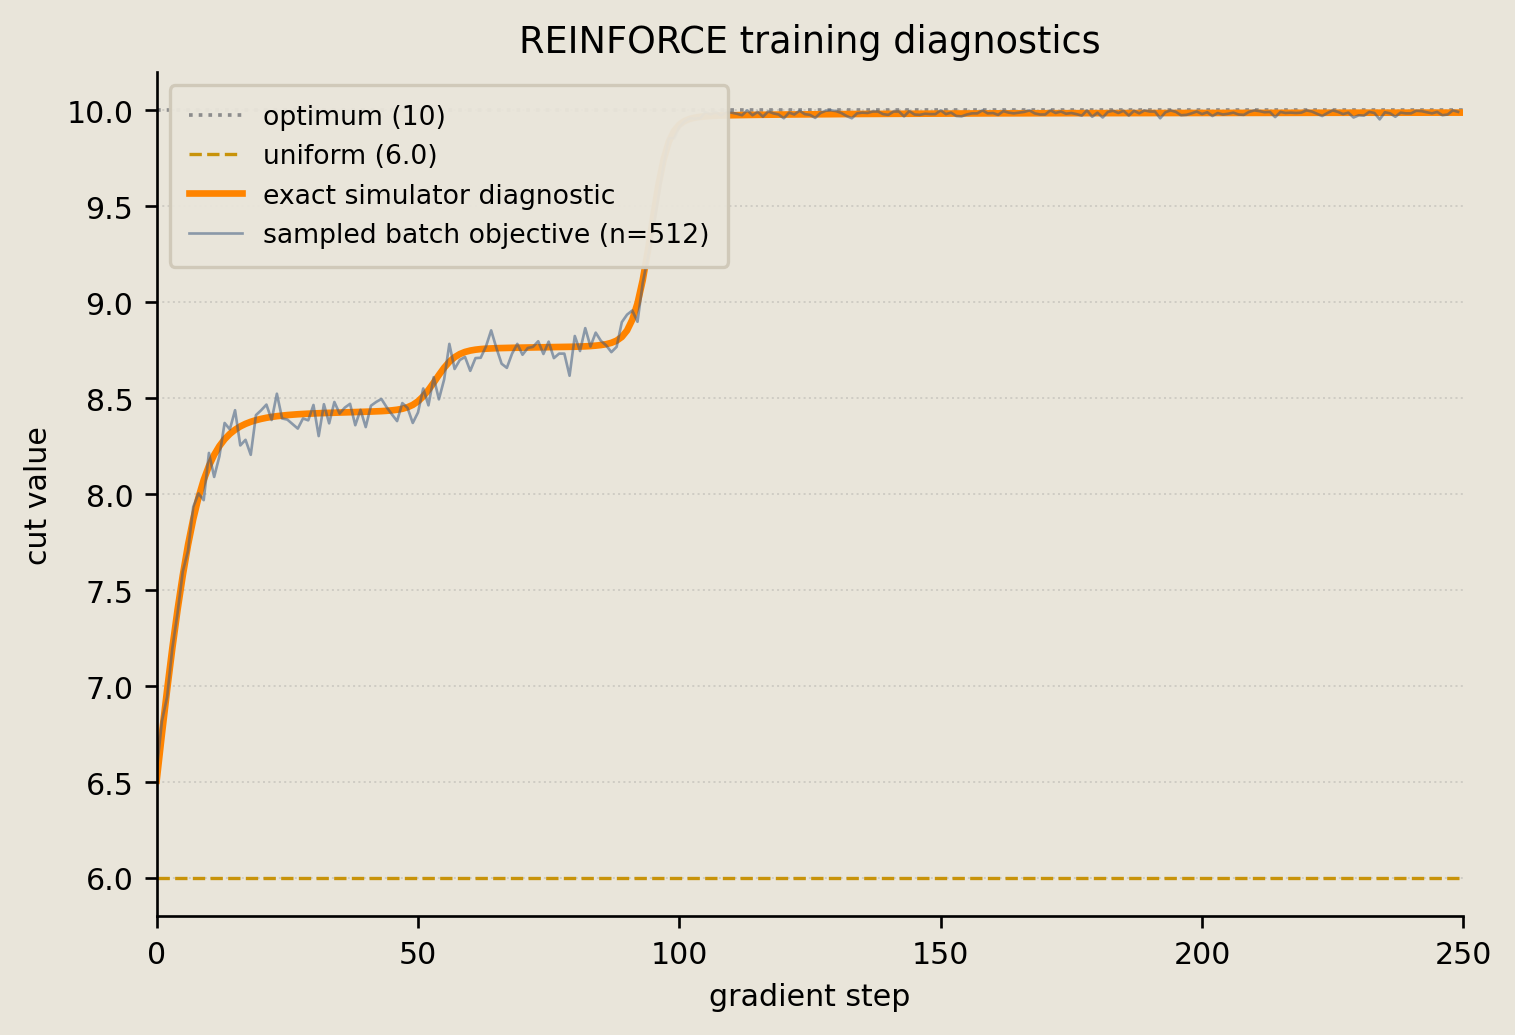

In [16]:
print(f"exact expected-cut diagnostic: {expected_hist[0]:.2f} -> {expected_hist[-1]:.2f}   (optimum {opt_cut})")
print(f"sampled batch objective:       {sampled_hist[0]:.2f} -> {sampled_hist[-1]:.2f}")
print(f"trained couplings: mean {float(J_star.mean()):.2f}, std {float(J_star.std()):.2f}")
assert expected_hist[-1] > expected_hist[0]
fig = plot_training_trajectory(
    expected_hist, sampled_hist, opt=opt_cut, uniform_mean=uniform_mean,
    num_samples=NUM_SAMPLES,
)
savefig(fig, "09_sgnn_training")

Both curves rise together from about 6.5 to 9.99 against an optimum of 10, which is the agreement we wanted: the sampled objective the optimizer follows tracks the exact expected cut rather than drifting away from it. The exact diagnostic carries one extra point because we evaluate it at the initial couplings before any update, while the sampled batch mean is recorded from the batch drawn at each step.

## What the circuit learned

Raising an average says nothing about where the probability went, so we now compare the exact cut distribution of the trained circuit against the uniform baseline.

In [17]:
# Convert exact output distributions into distributions over cut values.
rho_learned = np.asarray(density(J_star))
cut_support = np.arange(num_edges + 1)

uniform_dist = cut_distribution(
    np.full(2**NUM_NODES, 1.0 / 2**NUM_NODES),
    cut_values,
    num_edges,
)
learned_dist = cut_distribution(rho_learned, cut_values, num_edges)

learned mass on the optimum   : 0.996
learned mass on cut >= 9      : 0.997


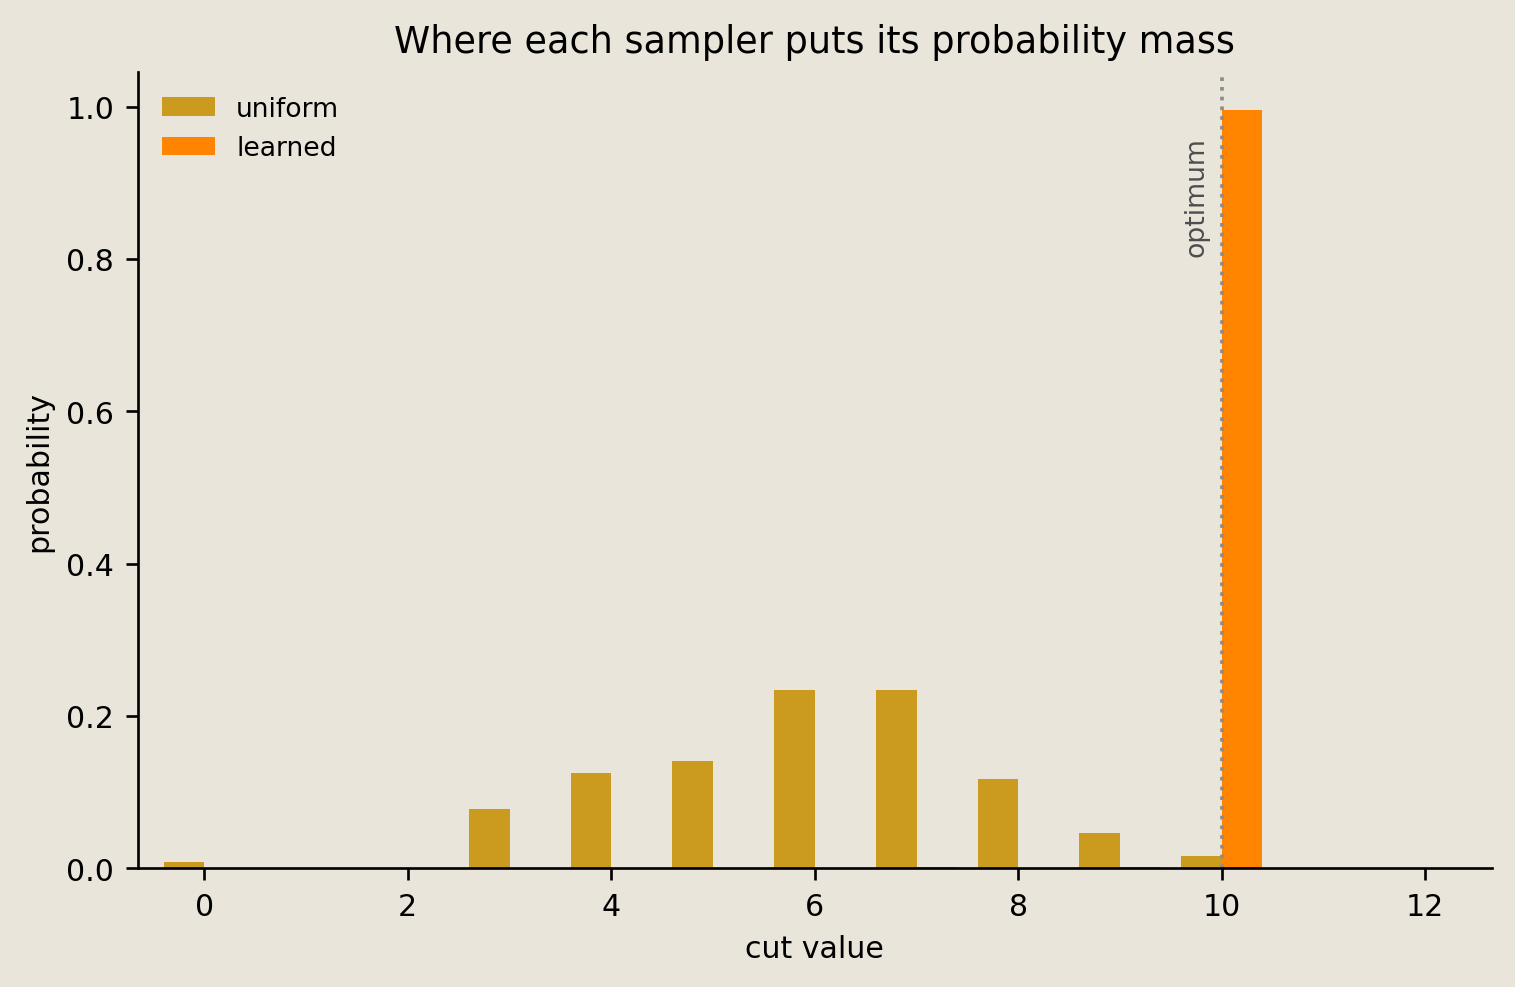

In [18]:
print(f"learned mass on the optimum   : {learned_dist[opt_cut]:.3f}")
print(
    f"learned mass on cut >= {opt_cut - 1}      : {learned_dist[opt_cut - 1:].sum():.3f}"
)

fig = plot_cut_distribution(
    cut_support,
    uniform_dist,
    learned_dist,
    opt=opt_cut,
)
savefig(fig, "09_sgnn_cut_distribution")

The trained circuit places 0.996 of its probability on the optimum itself and 0.997 within one edge of it, so training concentrated the distribution rather than merely nudging its mean. The uniform baseline stays spread around a mean cut of 6.00, far below the optimum of 10.

The distribution has a clear mode, so the natural question is which partition it is. We decode the most probable trained bitstring and draw it on the graph with its cut edges highlighted.

In [19]:
# Decode the most likely state index into one bit per graph node.
best_index = int(np.argmax(rho_learned))
partition = np.array(
    [(best_index >> (NUM_NODES - 1 - q)) & 1 for q in range(NUM_NODES)]
)
learned_cut = int(sum(partition[i] != partition[j] for i, j in edges))



most-probable bitstring cut: 10 / 12


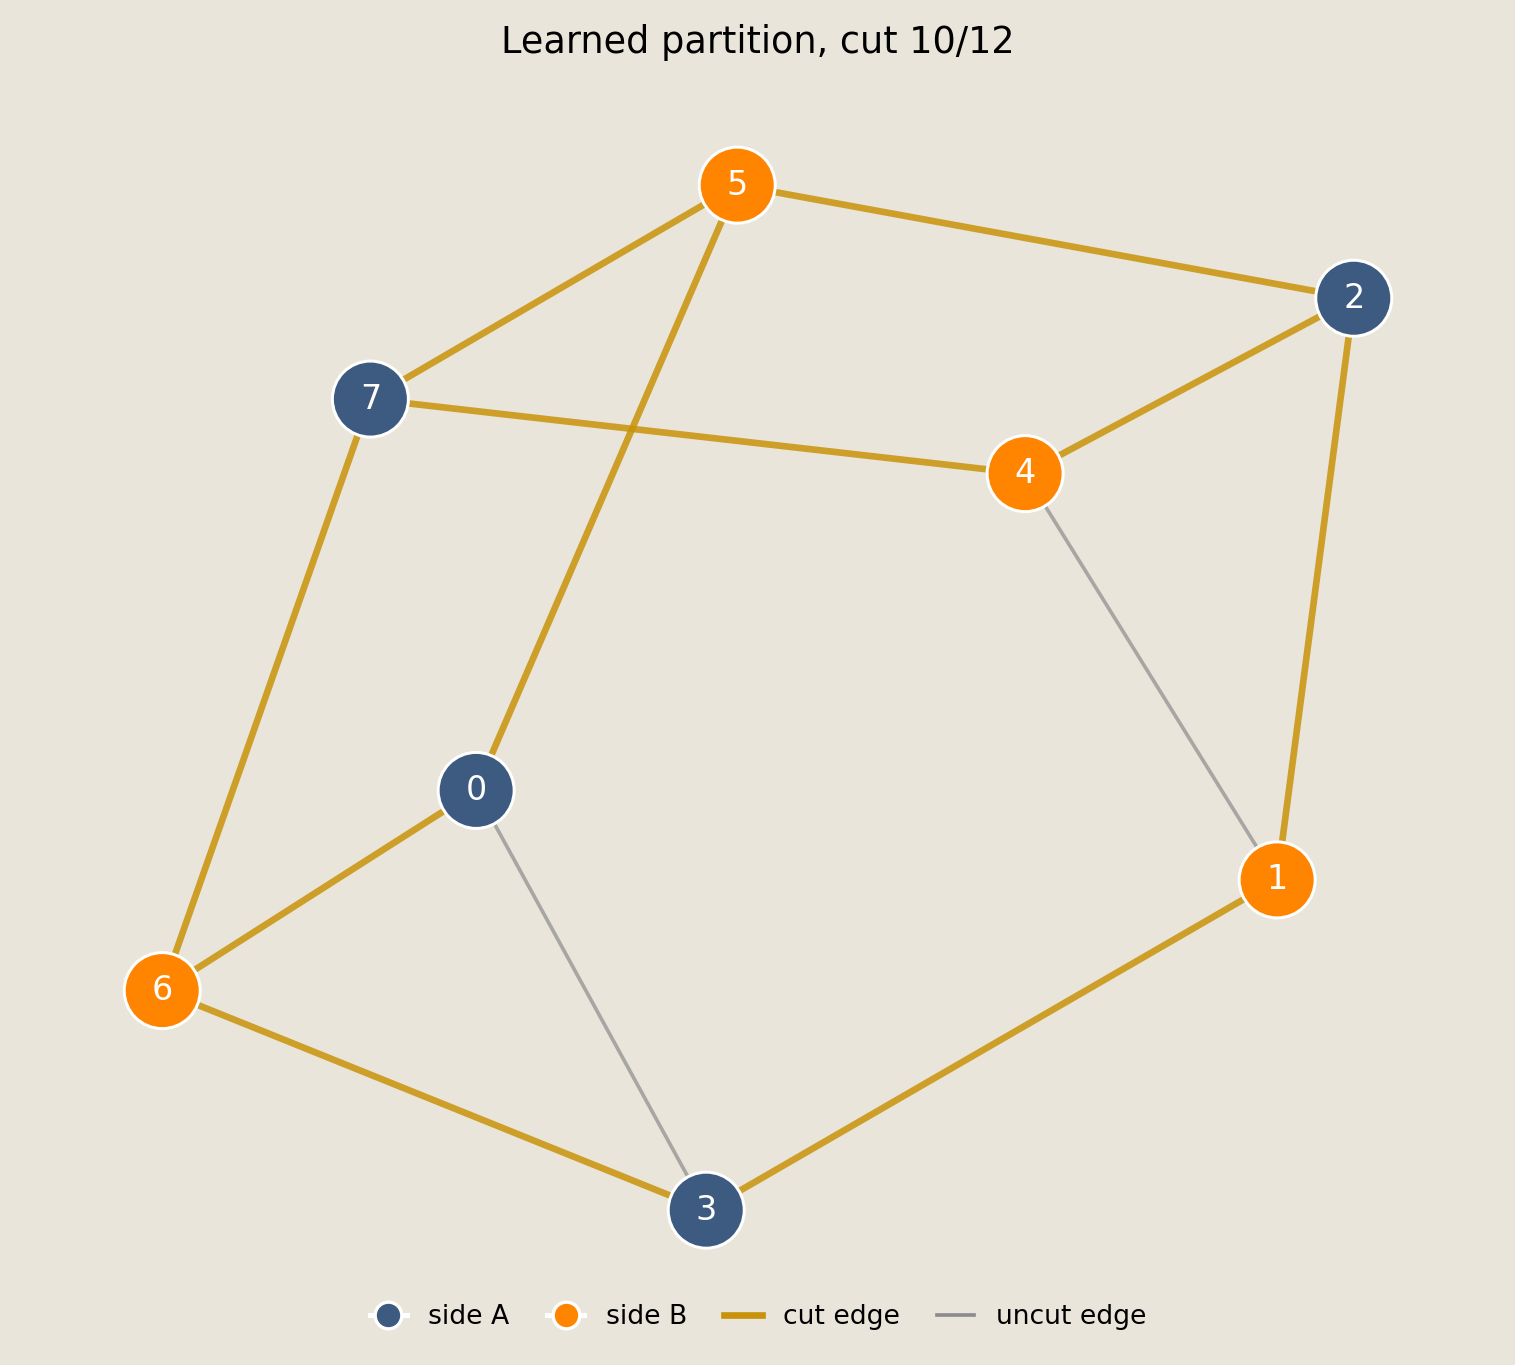

In [20]:
print(f"most-probable bitstring cut: {learned_cut} / {num_edges}")

fig = plot_partition(
    G,
    partition,
    learned_cut=learned_cut,
    num_edges=num_edges,
    layout_seed=GRAPH_SEED,
)
savefig(fig, "09_sgnn_graph")

Ten of the 12 edges are gold, which equals the brute-force optimum, so the mode of the trained distribution is an exact MaxCut solution. Gold edges cross the cut, and neutral gray edges join two nodes on the same side.

## Verification

Each check below tests one claim the figures rest on against a reference we can compute exactly.

- Every trained `PISING` matrix still has columns summing to one, which confirms the learned couplings describe a valid stochastic update rather than an arbitrary matrix.
- The final exact expected cut exceeds both its value at initialization and the uniform baseline, which establishes that REINFORCE training, and not the circuit's starting point, produced the improvement.
- More than half the trained probability mass sits on cuts within one edge of the optimum, which shows the circuit concentrates on good partitions instead of only shifting its average.
- The most probable trained bitstring attains the brute-force optimum, so the mode of the learned distribution is an exact solution.
- Three further graph seeds (11, 23, and 41) each finish above their own initial and uniform values and reach at least 80% of their brute-force optimum, which shows the result does not depend on the single graph drawn with `GRAPH_SEED`.

In [21]:
# 1) Each trained PISING edge is column-stochastic.
trained_mats = np.stack([edge_pising_matrix(float(j), beta=BETA, dt=DT) for j in J_star])
np.testing.assert_allclose(trained_mats.sum(axis=-2), 1.0, atol=1e-6)

# 2) REINFORCE training raised the expected cut past the uniform baseline.
assert expected_hist[-1] > expected_hist[0]
assert expected_hist[-1] > uniform_mean

# 3) The trained distribution concentrates on near-optimal cuts.
assert learned_dist[opt_cut - 1:].sum() > 0.5

# 4) The most-probable trained bitstring is an optimal cut.
assert learned_cut == opt_cut

In [22]:
# 5) Validation: print three other seeded graphs and enforce explicit thresholds.
validation_rows = []
for seed in (11, 23, 41):
    G_s, edges_s = random_regular_maxcut(NUM_NODES, DEGREE, seed=seed)
    ec_s, density_s = make_expected_cut(edges_s, NUM_NODES, beta=BETA, dt=DT, reps=REPS)
    cut_values_s, opt_s, _ = brute_force_cuts(edges_s, NUM_NODES)
    initial_s = float(ec_s(jnp.full((len(edges_s),), J_INIT)))
    uniform_s = float(cut_values_s.mean())
    J_s, expected_s, sampled_s = train_couplings(
        density_s, ec_s, cut_values_s, len(edges_s),
        steps=TRAIN_STEPS, num_samples=NUM_SAMPLES, lr=LEARNING_RATE,
        key=jax.random.PRNGKey(seed),
    )
    final_s = float(expected_s[-1])
    validation_rows.append((seed, initial_s, uniform_s, final_s, opt_s))
    assert final_s > initial_s
    assert final_s > uniform_s
    assert final_s >= 0.8 * opt_s
print("seed | initial | uniform | final | optimum | final/optimum")
for seed, initial_s, uniform_s, final_s, opt_s in validation_rows:
    print(f"{seed:4d} | {initial_s:7.3f} | {uniform_s:7.3f} | {final_s:5.3f} | {opt_s:7d} | {final_s / opt_s:13.1%}")

seed | initial | uniform | final | optimum | final/optimum
  11 |   6.512 |   6.000 | 8.759 |      10 |         87.6%
  23 |   6.494 |   6.000 | 8.874 |      10 |         88.7%
  41 |   6.541 |   6.000 | 8.813 |      10 |         88.1%


With the assertions passing, we print the headline numbers.

In [23]:
print("all checks passed")
print(f"  expected cut   {expected_hist[0]:.2f} -> {expected_hist[-1]:.2f}  (optimum {opt_cut})")
print(f"  learned mass on optimum   {learned_dist[opt_cut]:.3f}")
print(f"  uniform / learned : {uniform_mean:.2f} / {expected_hist[-1]:.2f}")

all checks passed
  expected cut   6.75 -> 9.99  (optimum 10)
  learned mass on optimum   0.996
  uniform / learned : 6.00 / 9.99


## Conclusion

We built a stochastic graph network for MaxCut with one `PISING` gate per edge, then trained its couplings with REINFORCE.

- Each sweep applies 12 column-stochastic Glauber updates sequentially in fixed edge-list order, then repeats that sweep 20 times.
- The estimator samples from the exact Torx probability vector and differentiates its selected exact log probabilities. Multiplying the same-batch centered surrogate by $M/(M-1)$ removes its finite-batch bias.
- The training figure keeps the sampled batch objective, which is what the optimizer sees, separate from the exact expected-cut diagnostic, which we evaluate before the first update and so starts at step zero.
- The exact learned distribution concentrates on high-cut partitions, and three additional graph seeds print their initial, uniform, final, optimum, and final-to-optimum values so the result can be judged beyond one graph.

See also:

- [`06_ising_sampling_contrastive_divergence.ipynb`](06_ising_sampling_contrastive_divergence.ipynb), which covers the `PISING` Glauber kernel and learning its couplings.
- [`04_execution_interface_readouts.ipynb`](04_execution_interface_readouts.ipynb), which covers how the simulators estimate expectations.
- [`08_stochastic_convolutional_networks.ipynb`](08_stochastic_convolutional_networks.ipynb), the sibling stochastic-network construction.

## References

1. <span id="ref-williams-1992"></span>Williams, R.J. 1992. [*Simple statistical gradient-following algorithms for connectionist reinforcement learning*](https://link.springer.com/article/10.1007/BF00992696). Mach. Learn. 8, 229-256.
2. <span id="ref-glauber-1963"></span>Glauber, R.J. 1963. [*Time-dependent statistics of the Ising model*](https://doi.org/10.1063/1.1703954). J. Math. Phys. 4, 294-307.